**DFINE-M Teacher**

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory free:  {free / 1e9:.2f} GB")
    print(f"GPU memory total: {total / 1e9:.2f} GB")

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory free:  84.65 GB
GPU memory total: 85.09 GB


In [ ]:
!pip install -q uv
!uv --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 102.3 MB/s eta 0:00:00
uv 0.11.10 (x86_64-unknown-linux-gnu)


In [ ]:
import os
from pathlib import Path

from google.colab import drive, userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

if not os.environ["HF_TOKEN"]:
    raise RuntimeError("Missing Colab secret: HF_TOKEN")

drive.mount("/content/drive")

REPO_DIR = Path("/content/adp")
DRIVE_ROOT = Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine")
DRIVE_RUNS = DRIVE_ROOT / "runs"
DRIVE_ARTIFACTS = DRIVE_ROOT / "artifacts"

DRIVE_RUNS.mkdir(parents=True, exist_ok=True)
DRIVE_ARTIFACTS.mkdir(parents=True, exist_ok=True)

print("HF_TOKEN set:", bool(os.environ["HF_TOKEN"]))
print("REPO_DIR:", REPO_DIR)
print("DRIVE_ROOT:", DRIVE_ROOT)
print("DRIVE_RUNS:", DRIVE_RUNS)
print("DRIVE_ARTIFACTS:", DRIVE_ARTIFACTS)

Mounted at /content/drive
HF_TOKEN set: True
REPO_DIR: /content/adp
DRIVE_ROOT: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine
DRIVE_RUNS: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs
DRIVE_ARTIFACTS: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts


In [ ]:
from pathlib import Path

PACKAGE_NAME = "bdd_det10_train30k_s42"

TEACHER_RUN_NAME = "train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30"
TEACHER_VIZ_RUN_NAME = "viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best"

TEACHER_RUN_DIR = Path(
    "/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/"
    "train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30"
)
TEACHER_VIZ_RUN_DIR = Path(
    "/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/"
    "viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best"
)

TEACHER_RUN_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 30
BATCH_SIZE = 64
IMG_SIZE = (544, 960)

BASE_LR = 0.00020
BACKBONE_LR = 0.00002
WEIGHT_DECAY = 0.00010
EMA_MOMENTUM = 0.9999
EVAL_EVERY = 2

print("PACKAGE_NAME:", PACKAGE_NAME)
print("TEACHER_RUN_NAME:", TEACHER_RUN_NAME)
print("TEACHER_RUN_DIR:", TEACHER_RUN_DIR)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)
print("IMG_SIZE:", IMG_SIZE)
print("BASE_LR:", BASE_LR)
print("BACKBONE_LR:", BACKBONE_LR)
print("WEIGHT_DECAY:", WEIGHT_DECAY)
print("EMA_MOMENTUM:", EMA_MOMENTUM)
print("EVAL_EVERY:", EVAL_EVERY)

PACKAGE_NAME: bdd_det10_train30k_s42
TEACHER_RUN_NAME: train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30
TEACHER_RUN_DIR: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30
EPOCHS: 30
BATCH_SIZE: 64
IMG_SIZE: (544, 960)
BASE_LR: 0.0002
BACKBONE_LR: 2e-05
WEIGHT_DECAY: 0.0001
EMA_MOMENTUM: 0.9999
EVAL_EVERY: 2


In [ ]:
%cd /content

!rm -rf adp ane-drive-perc
!git clone --branch v2-research-framework https://github.com/aekn/ane-drive-perc.git adp

%cd /content/adp
!git branch --show-current
!git rev-parse --short HEAD
!find src/adp -maxdepth 3 -type d | sort | head -100

/content
Cloning into 'adp'...
remote: Enumerating objects: 392, done.
remote: Counting objects: 100% (392/392), done.
remote: Compressing objects: 100% (245/245), done.
remote: Total 392 (delta 130), reused 364 (delta 102), pack-reused 0 (from 0)
Receiving objects: 100% (392/392), 389.99 KiB | 22.94 MiB/s, done.
Resolving deltas: 100% (130/130), done.
/content/adp
v2-research-framework
d51e87c
src/adp
src/adp/data
src/adp/eval
src/adp/model
src/adp/model/dfine
src/adp/model/dfine/arch
src/adp/train
src/adp/utils


In [ ]:
%cd /content/adp

!rm -rf .venv
!uv sync
!uv run python -c "import adp; print(adp.__file__)"
!uv run python -m compileall -q src

/content/adp
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 69 packages in 1ms
⠙ Preparing packages... (0/67)                                                  warning: `build_system.requires = ["uv-build>=0.9.21,<0.10.0"]` does not contain the current uv version 0.11.10
Prepared 67 packages in 32.99s
Installed 67 packages in 246ms
 + adp==0.1.0 (from file:///content/adp)
 + albucore==0.0.24
 + albumentations==2.0.8
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + antlr4-python3-runtime==4.9.3
 + anyio==4.13.0
 + certifi==2026.4.22
 + click==8.3.3
 + cuda-bindings==13.2.0
 + cuda-pathfinder==1.5.4
 + cuda-toolkit==13.0.2
 + filelock==3.29.0
 + fsspec==2026.4.0
 + h11==0.16.0
 + hf-xet==1.4.3
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.13.0
 + hydra-core==1.3.2
 + idna==3.13
 + jinja2==3.1.6
 + loguru==0.7.3
 + markdown-it-py==4.0.0
 + markupsafe==3.0.3
 + mdurl==0.1.2
 + mpmath==1.3.0
 + networkx==3.6.1
 + numpy==

In [ ]:
%cd /content/adp

!uv run python -u -m adp.data.stage \
  experiment.name=stage_bdd_det10_train30k_s42 \
  data.package_name=bdd_det10_train30k_s42 \
  hf.files.train_package=packages/bdd_det10_train30k_s42.tar \
  hf.files.train_checksum=checksums/bdd_det10_train30k_s42.sha256 \
  hf.files.val_package=packages/bdd_det10_val.tar \
  hf.files.val_checksum=checksums/bdd_det10_val.sha256 \
  stage.output_dir=data/staged/bdd_det10_train30k_s42 \
  stage.download_dir=data/downloads/hf/bdd_det10_train30k_s42

/content/adp
[adp] downloading train package
[2026-05-06 08:43:15,476][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/datasets/aekn/adp-bdd/resolve/main/packages/bdd_det10_train30k_s42.tar "HTTP/1.1 302 Found"
[2026-05-06 08:43:15,720][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/datasets/aekn/adp-bdd/xet-read-token/c63f78d214334af30ef5a8172a6932c56acd773b "HTTP/1.1 200 OK"
packages/bdd_det10_train30k_s42.tar: 100% 1.91G/1.91G [00:13<00:00, 142MB/s]
[2026-05-06 08:43:29,452][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/datasets/aekn/adp-bdd/resolve/main/checksums/bdd_det10_train30k_s42.sha256 "HTTP/1.1 200 OK"
[2026-05-06 08:43:29,712][httpx][INFO] - HTTP Request: GET https://huggingface.co/datasets/aekn/adp-bdd/resolve/main/checksums/bdd_det10_train30k_s42.sha256 "HTTP/1.1 200 OK"
bdd_det10_train30k_s42.sha256: 100% 93.0/93.0 [00:00<00:00, 486kB/s]
[adp] downloading val package
[2026-05-06 08:43:35,421][httpx][INFO] - HTTP Request: HEAD https://hug

In [ ]:
%cd /content/adp

!uv run python -m adp.data.validate \
  experiment.name=validate_staged_bdd_det10_train30k_s42 \
  data.root=data/staged/bdd_det10_train30k_s42

/content/adp
[adp] validation passed: /content/adp/runs/validate_staged_bdd_det10_train30k_s42/reports/dataset_validation.json
[adp] train images: 30000
[adp] train objects: 553161
[adp] val images: 10000
[adp] val objects: 185526


In [ ]:
%cd /content/adp

!uv run python -m adp.data.export_coco \
  experiment.name=export_coco_bdd_det10_train30k_s42 \
  data.root=data/staged/bdd_det10_train30k_s42 \
  data.package_name=bdd_det10_train30k_s42

/content/adp
[adp] wrote COCO export: /content/adp/data/exports/bdd_det10_train30k_s42/coco
[adp] train: 30000 images, 553161 objects -> /content/adp/data/exports/bdd_det10_train30k_s42/coco/annotations/instances_train.json
[adp] val: 10000 images, 185526 objects -> /content/adp/data/exports/bdd_det10_train30k_s42/coco/annotations/instances_val.json
[adp] overfit16: 16 images, 308 objects -> /content/adp/data/exports/bdd_det10_train30k_s42/coco/annotations/instances_overfit16.json
[adp] wrote metadata: /content/adp/data/exports/bdd_det10_train30k_s42/coco/metadata/export_coco.json


In [ ]:
%cd /content/adp

!python -m json.tool data/exports/bdd_det10_train30k_s42/coco/annotations/instances_train.json > /dev/null
!python -m json.tool data/exports/bdd_det10_train30k_s42/coco/annotations/instances_val.json > /dev/null
!python -m json.tool data/exports/bdd_det10_train30k_s42/coco/annotations/instances_overfit16.json > /dev/null

print("Train images:")
!find data/exports/bdd_det10_train30k_s42/coco/images/train \( -type l -o -type f \) | wc -l

print("Val images:")
!find data/exports/bdd_det10_train30k_s42/coco/images/val \( -type l -o -type f \) | wc -l

print("Annotation files:")
!ls -lh data/exports/bdd_det10_train30k_s42/coco/annotations

print("COCO metadata:")
!cat data/exports/bdd_det10_train30k_s42/coco/metadata/export_coco.json

/content/adp
Train images:
30000
Val images:
10000
Annotation files:
total 200M
-rw-r--r-- 1 root root  85K May  6 08:44 instances_overfit16.json
-rw-r--r-- 1 root root 150M May  6 08:44 instances_train.json
-rw-r--r-- 1 root root  50M May  6 08:44 instances_val.json
COCO metadata:
{
  "adp_class_id_to_coco_category_id": {
    "0": 1,
    "1": 2,
    "2": 3,
    "3": 4,
    "4": 5,
    "5": 6,
    "6": 7,
    "7": 8,
    "8": 9,
    "9": 10
  },
  "categories": [
    {
      "id": 1,
      "name": "pedestrian",
      "supercategory": "object"
    },
    {
      "id": 2,
      "name": "rider",
      "supercategory": "object"
    },
    {
      "id": 3,
      "name": "car",
      "supercategory": "object"
    },
    {
      "id": 4,
      "name": "truck",
      "supercategory": "object"
    },
    {
      "id": 5,
      "name": "bus",
      "supercategory": "object"
    },
    {
      "id": 6,
      "name": "train",
      "supercategory": "object"
    },
    {
      "id": 7,
      "name"

In [ ]:
%cd /content/adp

!mkdir -p /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30

!uv run python -u -m adp.train.train_dfine \
  experiment.name=train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30 \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs \
  data.root=data/staged/bdd_det10_train30k_s42 \
  data.package_name=bdd_det10_train30k_s42 \
  train.model_name=m \
  train.img_size=[544,960] \
  train.epochs=40 \
  train.batch_size=64 \
  train.num_workers=8 \
  train.device=cuda \
  train.amp_dtype=bfloat16 \
  train.use_ema=true \
  train.ema_momentum=0.9999 \
  train.augment=true \
  train.scheduler=onecycle \
  train.warmup_pct=0.05 \
  train.freeze_backbone_epochs=0 \
  train.base_lr=0.00020 \
  train.backbone_lr=0.00002 \
  train.weight_decay=0.00010 \
  train.eval_every=2 \
  train.train_annotations=instances_train.json \
  train.val_annotations=instances_val.json \
  2>&1 | tee /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/train.log

/content/adp
2026-05-06 08:45:10.167 | INFO     | __main__:main:114 - device: cuda
2026-05-06 08:45:10.168 | INFO     | __main__:main:115 - amp dtype: torch.bfloat16
2026-05-06 08:45:10.168 | INFO     | __main__:main:116 - image size: (544, 960)
2026-05-06 08:45:10.169 | INFO     | adp.model.dfine.utils:ensure_pretrained:218 - Pretrained weights not found at /content/adp/data/pretrained/dfine_m_obj2coco.pt; downloading from ArgoSA/D-FINE-seg
[2026-05-06 08:45:10,480][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/ArgoSA/D-FINE-seg/resolve/main/dfine_m_obj2coco.pt "HTTP/1.1 302 Found"
[2026-05-06 08:45:10,719][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/models/ArgoSA/D-FINE-seg/xet-read-token/dd827add98316da9e9e3ae26de983169838d9d4e "HTTP/1.1 200 OK"
2026-05-06 08:45:21.343 | INFO     | __main__:main:126 - pretrained: /content/adp/data/pretrained/dfine_m_obj2coco.pt
2026-05-06 08:45:21.715 | INFO     | adp.model.dfine.utils:load_tuning_state:188 - Pretrained we

In [ ]:
import json
from pathlib import Path

import pandas as pd

metrics_path = Path(
    "/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/"
    "train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/metrics.jsonl"
)

print("Metrics path:", metrics_path)
print("Metrics exists:", metrics_path.exists())

if not metrics_path.exists():
    run_dir = metrics_path.parent
    print("Available files:")
    for path in sorted(run_dir.rglob("*")) if run_dir.exists() else []:
        print(path)
    raise FileNotFoundError(metrics_path)

rows = [
    json.loads(line)
    for line in metrics_path.read_text().splitlines()
    if line.strip()
]

df = pd.DataFrame(rows)

metric_cols = [
    "epoch",
    "train/loss",
    "train/lr",
    "val/mAP",
    "val/mAP_50",
    "val/pred/count",
    "val/pred/score_mean",
    "val/pred/score_max",
    "val/pred/count_ge_0_05",
    "val/pred/count_ge_0_1",
    "val/pred/count_ge_0_3",
]
metric_cols = [col for col in metric_cols if col in df.columns]

print("Metric rows:", len(df))
print("Last epoch:", int(df["epoch"].max()))

print("\nBest epochs by val/mAP:")
display(df.sort_values("val/mAP", ascending=False)[metric_cols].head(10))

print("\nLast 10 epochs:")
display(df[metric_cols].tail(10))

Metrics path: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/metrics.jsonl
Metrics exists: True
Metric rows: 40
Last epoch: 39

Best epochs by val/mAP:


,epoch,train/loss,train/lr,val/mAP,val/mAP_50,val/pred/count,val/pred/score_mean,val/pred/score_max,val/pred/count_ge_0_05,val/pred/count_ge_0_1,val/pred/count_ge_0_3
13,13,21.348296,0.000155,0.343190,0.591393,3000000.0,0.151177,0.976562,2634551.0,1371175.0,318334.0
11,11,21.427750,0.000168,0.341969,0.589109,3000000.0,0.155593,0.972656,2719459.0,1486314.0,319317.0
15,15,21.280354,0.000140,0.341581,0.590126,3000000.0,0.152054,0.976562,2639142.0,1391654.0,318624.0
23,23,21.065713,0.000075,0.341532,0.590594,3000000.0,0.146972,0.976562,2524854.0,1285052.0,311112.0
17,17,21.221081,0.000125,0.341356,0.589129,3000000.0,0.149933,0.976562,2595580.0,1353272.0,314361.0
19,19,21.170976,0.000108,0.341252,0.589924,3000000.0,0.148691,0.976562,2566008.0,1321058.0,313695.0
21,21,21.119176,0.000092,0.341115,0.589759,3000000.0,0.147437,0.976562,2536989.0,1293714.0,312069.0
27,27,20.998907,0.000045,0.340512,0.588924,3000000.0,0.145847,0.976562,2491883.0,1259962.0,310128.0
25,25,21.028688,0.000060,0.339884,0.588283,3000000.0,0.145732,0.976562,2489948.0,1259517.0,309926.0
29,29,20.965087,0.000032,0.339771,0.588466,3000000.0,0.145599,0.976562,2484459.0,1256138.0,309400.0



Last 10 epochs:


,epoch,train/loss,train/lr,val/mAP,val/mAP_50,val/pred/count,val/pred/score_mean,val/pred/score_max,val/pred/count_ge_0_05,val/pred/count_ge_0_1,val/pred/count_ge_0_3
30,30,20.970688,2.641634e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,31,20.954146,2.107582e-05,0.338350,0.586764,3000000.0,0.145281,0.976562,2476436.0,1250009.0,308667.0
32,32,20.943286,1.627443e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,33,20.944759,1.204497e-05,0.338443,0.586621,3000000.0,0.144919,0.976562,2466624.0,1242792.0,308267.0
34,34,20.938600,8.416339e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,35,20.933112,5.413320e-06,0.338261,0.586733,3000000.0,0.144758,0.976562,2462372.0,1239074.0,308091.0
36,36,20.938158,3.056426e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,37,20.933846,1.361758e-06,0.338024,0.586399,3000000.0,0.144760,0.976562,2460896.0,1238892.0,308379.0
38,38,20.929909,3.408921e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,20.933147,8.015603e-10,0.337710,0.585758,3000000.0,0.144618,0.980469,2456842.0,1236006.0,308104.0


In [ ]:
import re
from pathlib import Path

epochs = 30
log_path = Path(
    "/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/"
    "train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/train.log"
)

text = log_path.read_text(errors="replace") if log_path.exists() else ""

epoch_seconds = []
for match in re.finditer(r"epoch\s+\d+\s+\|\s+(\d+)s\s+\|", text):
    epoch_seconds.append(int(match.group(1)))

if epoch_seconds:
    avg_epoch_sec = sum(epoch_seconds[-5:]) / min(5, len(epoch_seconds))
    estimated_total_hr = (avg_epoch_sec * epochs) / 3600
    print(f"Recent avg epoch seconds: {avg_epoch_sec:.1f}")
    print(f"Estimated {epochs}-epoch runtime: {estimated_total_hr:.2f} hours")
else:
    print("No epoch timing parsed yet.")

Recent avg epoch seconds: 758.2
Estimated 30-epoch runtime: 6.32 hours


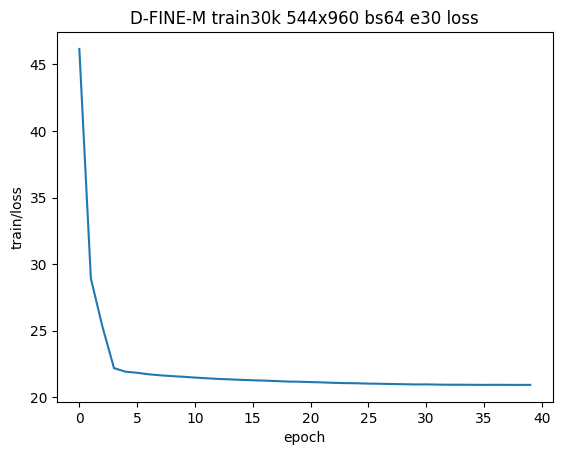

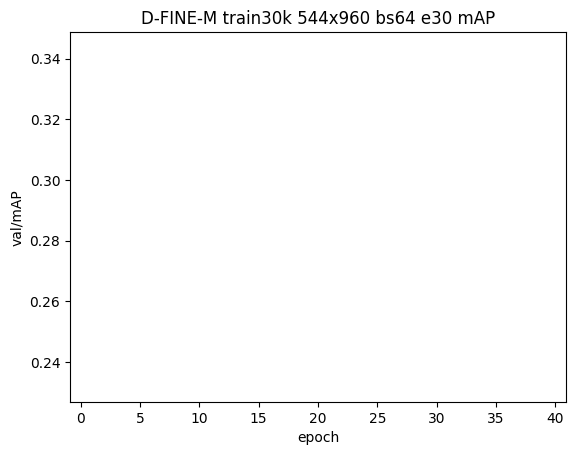

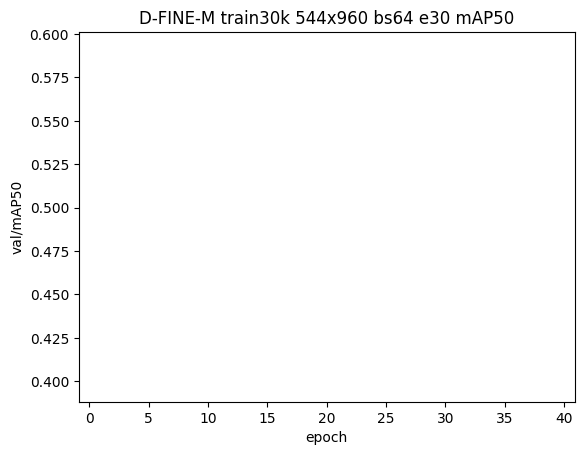

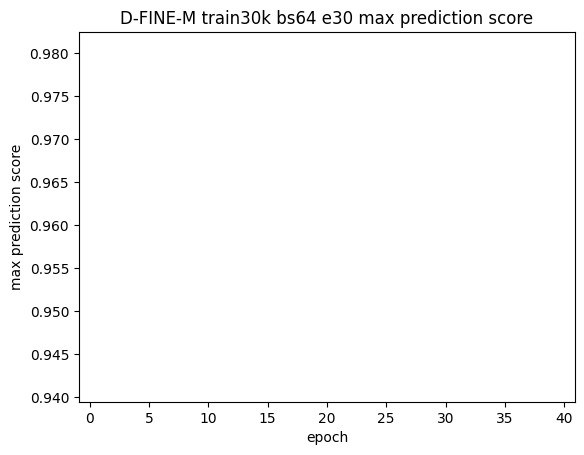

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["epoch"], df["train/loss"])
plt.xlabel("epoch")
plt.ylabel("train/loss")
plt.title("D-FINE-M train30k 544x960 bs64 e30 loss")
plt.show()

plt.figure()
plt.plot(df["epoch"], df["val/mAP"])
plt.xlabel("epoch")
plt.ylabel("val/mAP")
plt.title("D-FINE-M train30k 544x960 bs64 e30 mAP")
plt.show()

plt.figure()
plt.plot(df["epoch"], df["val/mAP_50"])
plt.xlabel("epoch")
plt.ylabel("val/mAP50")
plt.title("D-FINE-M train30k 544x960 bs64 e30 mAP50")
plt.show()

if "val/pred/score_max" in df.columns:
    plt.figure()
    plt.plot(df["epoch"], df["val/pred/score_max"])
    plt.xlabel("epoch")
    plt.ylabel("max prediction score")
    plt.title("D-FINE-M train30k bs64 e30 max prediction score")
    plt.show()

In [ ]:
%cd /content/adp

print("Teacher run files:")
!find /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30 -maxdepth 3 -type f | sort

print("\nCheckpoints:")
!ls -lh /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints

/content/adp
Teacher run files:
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/best.pt
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/last.pt
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/config.resolved.yaml
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/metrics.jsonl
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/train.log

Checkpoints:
total 599M
-rw------- 1 root root 300M May  6 12:35 best.pt
-rw------- 1 root root 300M May  6 19:29 last.pt


In [ ]:
%cd /content/adp

!uv run python -u -m adp.eval.visualize_predictions \
  experiment.name=viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs \
  data.package_name=bdd_det10_train30k_s42 \
  train.model_name=m \
  train.img_size=[544,960] \
  train.device=cuda \
  train.coco_root=data/exports/bdd_det10_train30k_s42/coco \
  train.val_annotations=instances_val.json \
  eval.checkpoint_path=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/best.pt \
  eval.score_threshold=0.3 \
  eval.nms_iou_threshold=0.6 \
  eval.class_agnostic_nms=false \
  eval.max_images=64 \
  eval.max_predictions_per_image=80 \
  eval.draw_prediction_labels=false \
  eval.vis_min_width=1280 \
  eval.vis_min_height=720

/content/adp
[adp] wrote 64 prediction visualizations: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best/debug/predictions
[adp] wrote report: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best/debug/prediction_visualization.json
[adp] ground truth = green
[adp] predictions = class colors shown in legend
[adp] visualization NMS IoU: 0.60
[adp] class-agnostic NMS: False


In [ ]:
from pathlib import Path

from IPython.display import display
from PIL import Image

prediction_dir = Path(
    "/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/"
    "viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best/debug/predictions"
)

prediction_paths = sorted(prediction_dir.glob("*.jpg"))

print("Prediction images:", len(prediction_paths))
print("Prediction dir:", prediction_dir)

for path in prediction_paths[:16]:
    image = Image.open(path)
    print(path.name, image.size)
    display(image)

In [ ]:
%cd /content/adp

!uv run python -m adp.utils.package_run \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs \
  artifacts.run_name=train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30 \
  artifacts.output_root=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts

/content/adp
[adp] packaged run directory: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30
[adp] wrote tarball: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30.tar.gz
[adp] best metrics: {
  "epoch": 13,
  "step": 6552,
  "train_secs": 758.0,
  "train/loss": 21.34829620214609,
  "train/lr": 0.00015468020746205223,
  "train/loss/loss_bbox": 0.06846467201781069,
  "train/loss/loss_bbox_aux_0": 0.06979230487257497,
  "train/loss/loss_bbox_aux_1": 0.06872042348910855,
  "train/loss/loss_bbox_aux_2": 0.06848263239058164,
  "train/loss/loss_bbox_dn_0": 0.06858081838641411,
  "train/loss/loss_bbox_dn_1": 0.0516741792870383,
  "train/loss/loss_bbox_dn_2": 0.04949505604867242,
  "train/loss/loss_bbox_dn_3": 0.04930785695552571,
  "train/loss/loss_bbox_dn_pre": 0.06866831244884902,
  "train/loss/loss_bbox_enc_0": 0.07275501993667875,
  "train/loss/loss_bbo

In [ ]:
%cd /content/adp

!uv run python -m adp.utils.package_run \
  paths.runs=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs \
  artifacts.run_name=viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best \
  artifacts.output_root=/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts

/content/adp
[adp] packaged run directory: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best
[adp] wrote tarball: /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best.tar.gz
[adp] best metrics: {}


In [ ]:
%cd /content/adp

!mkdir -p /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42

!cp -f data/staged/bdd_det10_train30k_s42/metadata/dataset.json \
  /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42/dataset.json

!cp -f data/exports/bdd_det10_train30k_s42/coco/metadata/export_coco.json \
  /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42/export_coco.json

!cp -f runs/validate_staged_bdd_det10_train30k_s42/reports/dataset_validation.json \
  /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42/dataset_validation.json || true

!find /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42 -maxdepth 2 -type f | sort

/content/adp
cp: cannot stat 'data/staged/bdd_det10_train30k_s42/metadata/dataset.json': No such file or directory
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42/dataset_validation.json
/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/dataset_bdd_det10_train30k_s42/export_coco.json


In [ ]:
from pathlib import Path

important_paths = [
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/config.resolved.yaml"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/metrics.jsonl"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/train.log"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/best.pt"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/last.pt"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best/debug/prediction_visualization.json"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30.tar.gz"),
    Path("/content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best.tar.gz"),
]

for path in important_paths:
    print(path.exists(), path)

True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/config.resolved.yaml
True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/metrics.jsonl
True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/train.log
True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/best.pt
True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30/checkpoints/last.pt
True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/runs/viz_train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30_best/debug/prediction_visualization.json
True /content/drive/MyDrive/projects/ane-drive-perc/runs/dfine/artifacts/train_dfine_m_bdd30k_544x960_teacher_a100_bs64_e30.tar.gz
True /content/drive/MyDri